# Academic Performance of Engineering Students
MSSP607 Assignment 1  
Tianyi Tan · University of Pennsylvania · September 30, 2026

I use the course dataset to compare assessment scores by parental education, stratum, gender, and engineering program. I start with group summaries, then add regressions to see how the comparisons change when other variables are included.

**To run:** Select **Runtime → Run all** in Colab. Upload the teacher's `data_academic_performance.xlsx` when asked. For local Jupyter, put the workbook beside the notebook or in `data/`. Tables and figures are saved in `results/`.

**Acknowledgement:** OpenAI Codex helped with coding, debugging, checking the results, and revisions. Claude (Anthropic) helped with additional analyses and drafting the report. I am responsible for the submitted work and its interpretation. The sources are cited in the report and notebook.

## 1. Load the data
The student data are in the `SABER11_SABERPRO` worksheet. The workbook also includes the data description and variable definitions.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

data_path = Path("data_academic_performance.xlsx")
if not data_path.exists() and Path("data/data_academic_performance.xlsx").exists():
    data_path = Path("data/data_academic_performance.xlsx")
if not data_path.exists():
    from google.colab import files
    print("Upload one course data file: .xlsx or .csv")
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Please upload one data file, then run this cell again.")
    data_path = Path(list(uploaded)[0])

if data_path.suffix.lower() == ".xlsx":
    raw = pd.read_excel(data_path, sheet_name="SABER11_SABERPRO")
elif data_path.suffix.lower() == ".csv":
    raw = pd.read_csv(data_path, encoding="utf-8-sig")
else:
    raise ValueError("Select the Excel or CSV data file, not the notebook or report.")

results = Path("results")
results.mkdir(exist_ok=True)
print("Original shape:", raw.shape)
display(raw.head())

Original shape: (12411, 45)


,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


## 2. Check and clean the data
I remove the empty column and spaces around category labels. I keep `0`, `Not sure`, and `Ninguno` separate because they have different meanings. I also check repeated test codes.

In [2]:
empty_columns = raw.columns[raw.isna().all()].tolist()
df = raw.drop(columns=empty_columns).copy()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('string').str.strip()

quality = {
    'rows': len(df), 'columns_after_cleaning': len(df.columns),
    'empty_columns_removed': empty_columns,
    'missing_cells_after_cleaning': int(df.isna().sum().sum()),
    'exact_duplicate_rows': int(df.duplicated().sum()),
    'repeated_high_school_codes': int(df['COD_S11'].duplicated().sum()),
    'repeated_professional_codes': int(df['Cod_SPro'].duplicated().sum()),
    'program_count': int(df['ACADEMIC_PROGRAM'].nunique())
}
display(pd.Series(quality, name='Value').to_frame())
for col in ['EDU_FATHER', 'EDU_MOTHER', 'STRATUM', 'SISBEN']:
    print(col, 'undocumented zero labels:', int(df[col].eq('0').sum()))
display(df['GENDER'].value_counts().rename('n').to_frame())
df.to_csv(results / 'cleaned_data.csv', index=False)

,Value
rows,12411
columns_after_cleaning,44
empty_columns_removed,[Unnamed: 9]
missing_cells_after_cleaning,0
exact_duplicate_rows,0
repeated_high_school_codes,0
repeated_professional_codes,16
program_count,21


EDU_FATHER undocumented zero labels: 391
EDU_MOTHER undocumented zero labels: 388
STRATUM undocumented zero labels: 14
SISBEN undocumented zero labels: 21


,n
GENDER,
M,7368
F,5043


## 3. Summarize the numerical variables
I calculate counts, means, standard deviations, and medians, both overall and by category. `2ND_DECILE`, `QUARTILE`, `SEL`, and `SEL_IHE` are category codes, so their means are not test scores. The two assessments use different scales; subtracting their raw scores would not measure learning gains.

In [3]:
score_cols = ['MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11', 'ENG_S11',
              'QR_PRO', 'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO', 'FEP_PRO', 'G_SC']
numeric_cols = score_cols + ['PERCENTILE', '2ND_DECILE', 'QUARTILE', 'SEL', 'SEL_IHE']
overall = df[numeric_cols].describe().T
display(overall.round(2))
overall.to_csv(results / 'overall_numerical_summary.csv')

# Full numerical summaries by the required and additional categories.
group_cols = ['EDU_FATHER', 'EDU_MOTHER', 'STRATUM', 'GENDER',
              'ACADEMIC_PROGRAM', 'SISBEN', 'SEL', 'SEL_IHE', 'SCHOOL_NAT', 'INTERNET']
for col in group_cols:
    grouped = df.groupby(col, dropna=False)[numeric_cols].agg(['count', 'mean', 'std', 'median'])
    grouped.to_csv(results / f'numerical_summary_by_{col}.csv')

,count,mean,std,min,25%,50%,75%,max
MAT_S11,12411.0,64.32,11.87,26.0,56.0,64.0,72.0,100.0
CR_S11,12411.0,60.78,10.03,24.0,54.0,61.0,67.0,100.0
CC_S11,12411.0,60.71,10.12,0.0,54.0,60.0,67.0,100.0
BIO_S11,12411.0,63.95,11.16,11.0,56.0,64.0,71.0,100.0
ENG_S11,12411.0,61.80,14.30,26.0,50.0,59.0,72.0,100.0
QR_PRO,12411.0,77.42,22.67,1.0,65.0,85.0,96.0,100.0
CR_PRO,12411.0,62.20,27.67,1.0,42.0,67.0,86.0,100.0
CC_PRO,12411.0,59.19,28.99,1.0,36.0,65.0,85.0,100.0
ENG_PRO,12411.0,67.50,25.50,1.0,51.0,74.0,88.0,100.0
WC_PRO,12411.0,53.70,30.00,0.0,28.0,56.0,80.0,100.0


## 4. Parental education
I compare global scores (`G_SC`) across each parent's education categories. The function below adds a 95% confidence interval to each group mean. I use the same function for later comparisons.

In [4]:
def global_summary(frame, category):
    table = frame.groupby(category, dropna=False)['G_SC'].agg(n='count', mean='mean', sd='std', median='median')
    table['se'] = table['sd'] / np.sqrt(table['n'])
    margin = stats.t.ppf(0.975, table['n'] - 1) * table['se']
    table['ci_low'] = table['mean'] - margin
    table['ci_high'] = table['mean'] + margin
    return table

father = global_summary(df, 'EDU_FATHER').sort_values('mean')
mother = global_summary(df, 'EDU_MOTHER').sort_values('mean')
display(father.rename(index={'Ninguno': 'None'}).round(2))
display(mother.rename(index={'Ninguno': 'None'}).round(2))
father.to_csv(results / 'father_global.csv')
mother.to_csv(results / 'mother_global.csv')
for label, table in [('Father', father), ('Mother', mother)]:
    gap = table.loc['Postgraduate education', 'mean'] - table.loc['Complete Secundary', 'mean']
    print(f'{label}: postgraduate minus completed secondary = {gap:.2f} global-score points')

,n,mean,sd,median,se,ci_low,ci_high
EDU_FATHER,,,,,,,
0,391,155.08,20.06,155.0,1.01,153.08,157.07
Complete primary,824,155.20,22.41,155.0,0.78,153.66,156.73
Incomplete primary,735,155.73,20.94,156.0,0.77,154.21,157.25
Incomplete Secundary,1091,156.54,21.74,157.0,0.66,155.24,157.83
None,123,156.63,23.19,159.0,2.09,152.50,160.77
Complete Secundary,2843,158.79,22.11,159.0,0.41,157.97,159.60
Not sure,407,160.29,22.94,159.0,1.14,158.06,162.53
Incomplete technical or technological,277,162.10,21.88,162.0,1.31,159.51,164.69
Complete technique or technology,1194,164.03,22.17,164.0,0.64,162.77,165.29


,n,mean,sd,median,se,ci_low,ci_high
EDU_MOTHER,,,,,,,
None,34,149.71,27.93,152.5,4.79,139.96,159.45
Incomplete primary,541,154.85,21.64,155.0,0.93,153.03,156.68
0,388,154.93,19.95,155.0,1.01,152.94,156.92
Complete primary,713,155.34,22.01,155.0,0.82,153.72,156.96
Incomplete Secundary,1056,155.67,21.93,156.0,0.67,154.35,157.00
Complete Secundary,3106,158.47,21.95,159.0,0.39,157.70,159.24
Not sure,179,159.41,25.47,159.0,1.90,155.65,163.16
Incomplete technical or technological,341,161.88,20.74,164.0,1.12,159.67,164.09
Complete technique or technology,1495,163.24,21.94,163.0,0.57,162.13,164.36


Father: postgraduate minus completed secondary = 18.20 global-score points
Mother: postgraduate minus completed secondary = 17.17 global-score points


## 5. Stratum and other groups
I compare Strata 1–6, then look at SISBEN, socioeconomic level, school type, and internet access. SISBEN records a classification; it does not tell us whether a student received a grant.

In [5]:
strata = global_summary(df, 'STRATUM')
display(strata.round(2))
strata.to_csv(results / 'stratum_global.csv')
print('Stratum 6 minus Stratum 1:', round(strata.loc['Stratum 6', 'mean'] - strata.loc['Stratum 1', 'mean'], 2))
for col in ['SISBEN', 'SEL', 'SCHOOL_NAT', 'INTERNET']:
    table = global_summary(df, col)
    print(col)
    display(table.round(2))
    table.to_csv(results / f'global_by_{col}.csv')

,n,mean,sd,median,se,ci_low,ci_high
STRATUM,,,,,,,
0,14,154.00,21.32,152.5,5.70,141.69,166.31
Stratum 1,1709,152.35,21.94,152.0,0.53,151.31,153.39
Stratum 2,4029,158.20,22.28,158.0,0.35,157.51,158.89
Stratum 3,4045,163.82,21.69,164.0,0.34,163.15,164.48
Stratum 4,1578,172.00,21.47,174.0,0.54,170.94,173.06
Stratum 5,633,177.39,21.54,179.0,0.86,175.71,179.07
Stratum 6,403,181.51,21.88,184.0,1.09,179.37,183.65


Stratum 6 minus Stratum 1: 29.16
SISBEN


,n,mean,sd,median,se,ci_low,ci_high
SISBEN,,,,,,,
0,21,158.62,20.09,156.0,4.38,149.48,167.76
Esta clasificada en otro Level del SISBEN,96,166.05,22.51,167.0,2.30,161.49,170.61
It is not classified by the SISBEN,7534,167.47,22.48,169.0,0.26,166.96,167.98
Level 1,2057,152.68,21.66,152.0,0.48,151.74,153.62
Level 2,2120,155.89,22.27,156.0,0.48,154.94,156.84
Level 3,583,160.99,21.64,161.0,0.90,159.23,162.75


SEL


,n,mean,sd,median,se,ci_low,ci_high
SEL,,,,,,,
1,2138,155.47,21.80,155.0,0.47,154.55,156.40
2,4742,158.54,22.32,159.0,0.32,157.91,159.18
3,1491,162.30,22.02,162.0,0.57,161.18,163.42
4,4040,171.58,22.35,173.0,0.35,170.89,172.27


SCHOOL_NAT


,n,mean,sd,median,se,ci_low,ci_high
SCHOOL_NAT,,,,,,,
PRIVATE,6565,168.22,22.82,170.0,0.28,167.66,168.77
PUBLIC,5846,156.53,21.84,157.0,0.29,155.97,157.09


INTERNET


,n,mean,sd,median,se,ci_low,ci_high
INTERNET,,,,,,,
No,2659,154.62,22.21,154.0,0.43,153.77,155.46
Yes,9752,164.92,22.86,166.0,0.23,164.46,165.37


### 5b. Which strata differ
Tukey's test compares all 15 pairs of strata. I also compare subjects and standardize the high-school average and university global score. The z-scores show relative position within this sample, rather than learning gains.

In [6]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

known_strata = df[df["STRATUM"] != "0"]
tukey = pairwise_tukeyhsd(known_strata["G_SC"].to_numpy(), known_strata["STRATUM"].astype(str).to_numpy(), alpha=0.05)
tukey_table = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
display(tukey_table)
tukey_table.to_csv(results / "stratum_tukey.csv", index=False)

# Domain means by stratum: which skills are most stratified?
s11_cols = ["MAT_S11", "CR_S11", "CC_S11", "BIO_S11", "ENG_S11"]
pro_cols = ["QR_PRO", "CR_PRO", "CC_PRO", "ENG_PRO", "WC_PRO"]
domain_by_stratum = known_strata.groupby("STRATUM")[s11_cols + pro_cols + ["G_SC"]].mean()
display(domain_by_stratum.round(1))
domain_by_stratum.to_csv(results / "domain_means_by_stratum.csv")

# Standardised position at the two moments, so the two scales can be compared.
df["S11_AVG"] = df[s11_cols].mean(axis=1)
df["z_S11"] = (df["S11_AVG"] - df["S11_AVG"].mean()) / df["S11_AVG"].std()
df["z_GSC"] = (df["G_SC"] - df["G_SC"].mean()) / df["G_SC"].std()
z_by_stratum = df[df["STRATUM"] != "0"].groupby("STRATUM")[["z_S11", "z_GSC"]].mean()
z_by_stratum["change"] = z_by_stratum["z_GSC"] - z_by_stratum["z_S11"]
display(z_by_stratum.round(2))
z_by_stratum.to_csv(results / "stratum_zscores.csv")
print("Correlation between the Saber 11 average and G_SC:", round(df["S11_AVG"].corr(df["G_SC"]), 3))

# Compare Strata 6 and 1 within each domain using a pooled SD.
stratum_rows = []
for col in s11_cols + pro_cols:
    high = df.loc[df["STRATUM"] == "Stratum 6", col]
    low = df.loc[df["STRATUM"] == "Stratum 1", col]
    pooled = np.sqrt(((len(high) - 1) * high.var() + (len(low) - 1) * low.var()) / (len(high) + len(low) - 2))
    stratum_rows.append({"domain": col, "gap_6_minus_1": high.mean() - low.mean(),
                         "cohens_d": (high.mean() - low.mean()) / pooled})
stratum_domain_gaps = pd.DataFrame(stratum_rows).set_index("domain")
display(stratum_domain_gaps.round(3))
stratum_domain_gaps.to_csv(results / "stratum_domain_gaps.csv")


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Stratum 1,Stratum 2,5.8465,0.0000,4.0455,7.6474,True
1,Stratum 1,Stratum 3,11.4625,0.0000,9.6626,13.2624,True
2,Stratum 1,Stratum 4,19.6497,0.0000,17.4716,21.8278,True
3,Stratum 1,Stratum 5,25.0342,0.0000,22.1314,27.9370,True
4,Stratum 1,Stratum 6,29.1583,0.0000,25.7035,32.6131,True
5,Stratum 2,Stratum 3,5.6160,0.0000,4.2274,7.0046,True
6,Stratum 2,Stratum 4,13.8032,0.0000,11.9505,15.6560,True
7,Stratum 2,Stratum 5,19.1877,0.0000,16.5204,21.8551,True
8,Stratum 2,Stratum 6,23.3119,0.0000,20.0524,26.5713,True
9,Stratum 3,Stratum 4,8.1872,0.0000,6.3355,10.0389,True


,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,G_SC
STRATUM,,,,,,,,,,,
Stratum 1,59.8,57.1,57.3,60.2,53.4,70.5,53.6,50.9,50.9,49.3,152.4
Stratum 2,62.1,59.1,59.2,62.1,57.2,74.6,58.8,56.0,60.9,51.1,158.2
Stratum 3,64.3,61.5,61.3,64.0,62.4,78.3,63.9,60.2,70.6,53.0,163.8
Stratum 4,69.1,64.1,63.6,67.7,69.8,83.2,69.3,67.0,80.1,59.6,172.0
Stratum 5,72.1,65.5,64.9,71.0,77.0,86.7,71.7,69.2,87.0,63.7,177.4
Stratum 6,74.7,66.0,66.7,72.7,82.4,88.4,73.8,71.1,92.5,65.6,181.5


,z_S11,z_GSC,change
STRATUM,,,
Stratum 1,-0.49,-0.45,0.04
Stratum 2,-0.25,-0.20,0.05
Stratum 3,0.04,0.05,0.01
Stratum 4,0.47,0.40,-0.07
Stratum 5,0.81,0.64,-0.17
Stratum 6,1.05,0.81,-0.24


Correlation between the Saber 11 average and G_SC: 0.778


,gap_6_minus_1,cohens_d
domain,,
MAT_S11,14.821,1.327
CR_S11,8.931,0.920
CC_S11,9.405,0.963
BIO_S11,12.439,1.141
ENG_S11,28.948,2.742
QR_PRO,17.842,0.757
CR_PRO,20.198,0.731
CC_PRO,20.156,0.712
ENG_PRO,41.542,1.726


## 6. Gender
I compare female and male global scores using Welch's t-test. Cohen's d shows the size of the gap relative to variation within the groups.

In [7]:
gender = global_summary(df, "GENDER")
gender_domains = df.groupby("GENDER")[score_cols + ["PERCENTILE"]].mean()
display(gender.round(2))
display(gender_domains.round(2))
gender.to_csv(results / "gender_global.csv")
gender_domains.to_csv(results / "gender_domains.csv")

female = df.loc[df["GENDER"] == "F", "G_SC"]
male = df.loc[df["GENDER"] == "M", "G_SC"]
gap = male.mean() - female.mean()

# Cohen's d uses the pooled within-group standard deviation.
pooled_variance = (
    (len(male) - 1) * male.var() + (len(female) - 1) * female.var()
) / (len(male) + len(female) - 2)
d = gap / np.sqrt(pooled_variance)

test_gender = stats.ttest_ind(male, female, equal_var=False)
interval = test_gender.confidence_interval()
gap_ci = np.array([interval.low, interval.high])
print(f"Male minus female mean: {gap:.2f} points")
print(f"95% confidence interval: {interval.low:.2f} to {interval.high:.2f}")
print(f"Cohen's d: {d:.3f}; Welch p-value: {test_gender.pvalue:.3g}")

,n,mean,sd,median,se,ci_low,ci_high
GENDER,,,,,,,
F,5043,161.28,22.33,162.0,0.31,160.66,161.89
M,7368,163.69,23.58,164.0,0.27,163.15,164.23


,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE
GENDER,,,,,,,,,,,,,
F,61.93,60.9,59.96,62.27,61.45,71.89,61.34,58.57,66.53,56.62,145.3,161.28,67.13
M,65.96,60.7,61.22,65.10,62.04,81.20,62.79,59.61,68.16,51.71,145.6,163.69,69.35


Male minus female mean: 2.41 points
95% confidence interval: 1.59 to 3.23
Cohen's d: 0.105; Welch p-value: 7.79e-09


### 6b. Gender differences by subject
A positive Cohen's d means the male mean is higher; a negative value means the female mean is higher. These are unadjusted comparisons. The subject tests are exploratory and do not adjust for multiple testing.

In [8]:
def cohens_d(a, b):
    pooled = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var()) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / pooled

domain_rows = []
for col in s11_cols + pro_cols + ["G_SC"]:
    m = df.loc[df["GENDER"] == "M", col]
    f = df.loc[df["GENDER"] == "F", col]
    domain_rows.append({"domain": col, "mean_F": f.mean(), "mean_M": m.mean(),
                        "gap_M_minus_F": m.mean() - f.mean(), "cohens_d": cohens_d(m, f),
                        "welch_p": stats.ttest_ind(m, f, equal_var=False).pvalue})
gender_by_domain = pd.DataFrame(domain_rows).set_index("domain")
display(gender_by_domain.round(3))
gender_by_domain.to_csv(results / "gender_by_domain.csv")

,mean_F,mean_M,gap_M_minus_F,cohens_d,welch_p
domain,,,,,
MAT_S11,61.932,65.955,4.023,0.344,0.000
CR_S11,60.895,60.698,-0.197,-0.020,0.280
CC_S11,59.960,61.215,1.255,0.124,0.000
BIO_S11,62.268,65.102,2.834,0.256,0.000
ENG_S11,61.451,62.041,0.589,0.041,0.023
QR_PRO,71.893,81.199,9.306,0.419,0.000
CR_PRO,61.339,62.788,1.450,0.052,0.004
CC_PRO,58.574,59.606,1.032,0.036,0.049
ENG_PRO,66.532,68.159,1.627,0.064,0.000


## 7. Engineering programs
I show the six programs with at least 100 records. The full table is saved as a CSV. Small groups have less stable averages. I also compare gender means within each program.

In [9]:
program = global_summary(df, 'ACADEMIC_PROGRAM').sort_values('mean', ascending=False)
program.to_csv(results / 'program_global.csv')
large_programs = program[program['n'] >= 100]
print('Programs with at least 100 records:')
display(large_programs.round(2))
within_program = df.groupby(['ACADEMIC_PROGRAM', 'GENDER'])['G_SC'].agg(['count', 'mean']).unstack('GENDER')
within_program[('gap_M_minus_F', '')] = within_program[('mean', 'M')] - within_program[('mean', 'F')]
display(within_program.loc[large_programs.index].round(2))
within_program.to_csv(results / 'gender_within_program.csv')

Programs with at least 100 records:


,n,mean,sd,median,se,ci_low,ci_high
ACADEMIC_PROGRAM,,,,,,,
CHEMICAL ENGINEERING,1000,176.70,18.69,177.0,0.59,175.54,177.86
ELECTRIC ENGINEERING,278,173.99,19.35,174.5,1.16,171.70,176.27
ELECTRONIC ENGINEERING,849,166.87,22.20,167.0,0.76,165.38,168.37
MECHANICAL ENGINEERING,1135,166.05,23.26,166.0,0.69,164.70,167.41
CIVIL ENGINEERING,3320,161.11,22.83,161.0,0.40,160.33,161.89
INDUSTRIAL ENGINEERING,5318,159.04,23.16,159.0,0.32,158.42,159.67


count            mean         gap_M_minus_F
GENDER                       F       M       F       M              
ACADEMIC_PROGRAM                                                    
CHEMICAL ENGINEERING     545.0   455.0  174.84  178.93          4.09
ELECTRIC ENGINEERING      61.0   217.0  171.51  174.69          3.18
ELECTRONIC ENGINEERING   166.0   683.0  165.31  167.25          1.95
MECHANICAL ENGINEERING   137.0   998.0  167.46  165.86         -1.60
CIVIL ENGINEERING       1191.0  2129.0  159.32  162.11          2.79
INDUSTRIAL ENGINEERING  2764.0  2554.0  158.24  159.91          1.66

### 7b. Compare programs after accounting for high-school scores
I predict `G_SC` from the five Saber 11 subjects. A residual is the observed score minus the predicted score. The average residual gives each program a baseline comparison, but it does not measure teaching quality. I also summarize writing scores and female representation.

In [10]:
import statsmodels.formula.api as smf

va_fit = smf.ols("G_SC ~ " + " + ".join(s11_cols), data=df).fit()
df["RESIDUAL"] = va_fit.resid
print("R-squared for the high-school score model:", round(va_fit.rsquared, 3))
program_adjusted = df.groupby("ACADEMIC_PROGRAM").agg(
    n=("G_SC", "size"),
    mean_S11=("S11_AVG", "mean"),
    mean_GSC=("G_SC", "mean"),
    value_added=("RESIDUAL", "mean")
)
program_adjusted["raw_gap_vs_all"] = program_adjusted["mean_GSC"] - df["G_SC"].mean()
program_adjusted = program_adjusted[program_adjusted["n"] >= 100].sort_values("value_added", ascending=False)
display(program_adjusted.round(2))
program_adjusted.to_csv(results / "program_value_added.csv")

program_support = df.groupby("ACADEMIC_PROGRAM").agg(
    n=("G_SC", "size"), writing_mean=("WC_PRO", "mean"),
    female_share_pct=("GENDER", lambda x: 100 * (x == "F").mean()))
program_support = program_support.loc[program_adjusted.index]
display(program_support.round(2))
program_support.to_csv(results / "program_support.csv")


R-squared for the high-school score model: 0.609


,n,mean_S11,mean_GSC,value_added,raw_gap_vs_all
ACADEMIC_PROGRAM,,,,,
CHEMICAL ENGINEERING,1000,67.97,176.70,3.31,13.99
ELECTRIC ENGINEERING,278,68.04,173.99,1.00,11.28
CIVIL ENGINEERING,3320,61.43,161.11,0.18,-1.60
INDUSTRIAL ENGINEERING,5318,60.52,159.04,-0.47,-3.67
ELECTRONIC ENGINEERING,849,65.13,166.87,-0.90,4.16
MECHANICAL ENGINEERING,1135,64.79,166.05,-1.20,3.34


,n,writing_mean,female_share_pct
ACADEMIC_PROGRAM,,,
CHEMICAL ENGINEERING,1000,63.99,54.50
ELECTRIC ENGINEERING,278,57.82,21.94
CIVIL ENGINEERING,3320,51.31,35.87
INDUSTRIAL ENGINEERING,5318,54.15,51.97
ELECTRONIC ENGINEERING,849,51.16,19.55
MECHANICAL ENGINEERING,1135,50.49,12.07


## 8. Figures
The first two figures show means with 95% confidence intervals. The gender boxplot hides outlier markers, but all scores remain in the calculations. The program figure uses groups with at least 100 records.

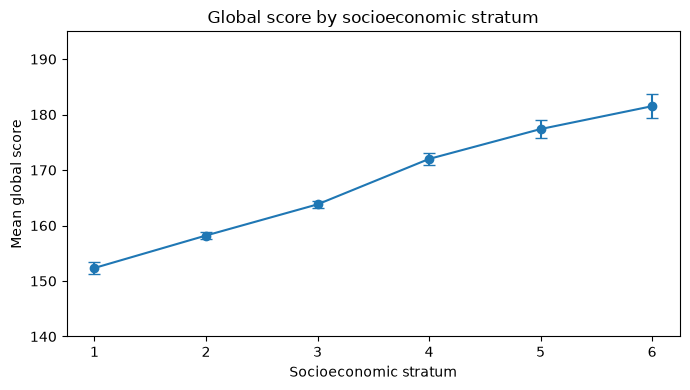

In [11]:
# Figure 1: Global scores by stratum.
ordered = strata.loc[[f"Stratum {i}" for i in range(1, 7)]]
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(range(1, 7), ordered["mean"],
            yerr=ordered["mean"] - ordered["ci_low"], fmt="o-", capsize=4)
ax.set(xlabel="Socioeconomic stratum", ylabel="Mean global score",
       xticks=range(1, 7), ylim=(140, 195))
ax.set_title("Global score by socioeconomic stratum")
fig.tight_layout()
fig.savefig(results / "figure1_stratum.png", dpi=200)
plt.show()

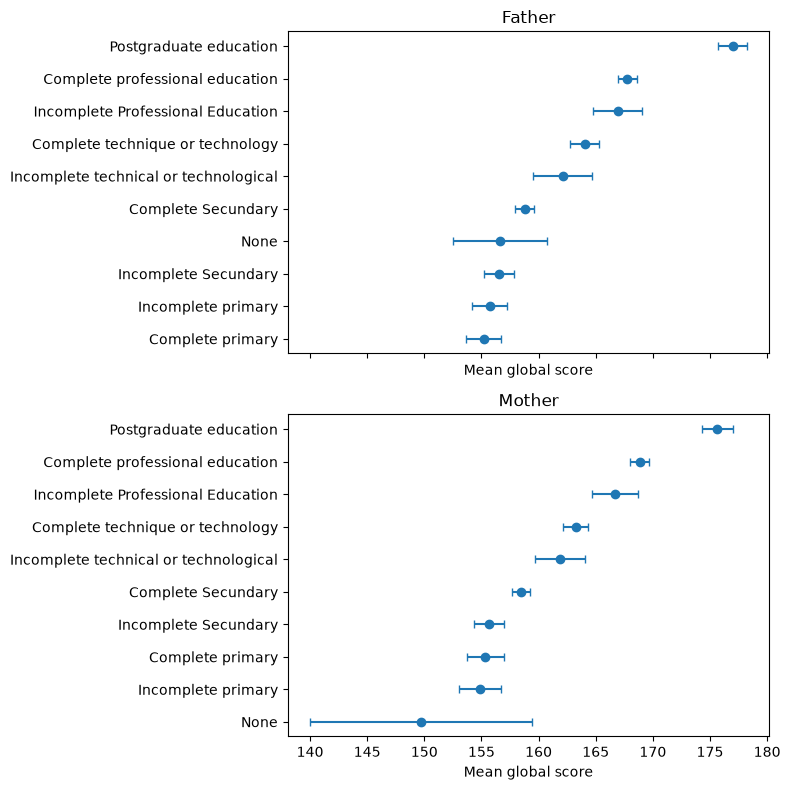

In [12]:
# Figure 2: Global scores by parental education.
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
for ax, title, table in zip(axes, ["Father", "Mother"], [father, mother]):
    known = table.drop(index=["0", "Not sure"])
    known = known.rename(index={"Ninguno": "None"})
    ax.errorbar(known["mean"], range(len(known)),
                xerr=known["mean"] - known["ci_low"], fmt="o", capsize=3)
    ax.set_yticks(range(len(known)), known.index)
    ax.set(xlabel="Mean global score", title=title)
fig.tight_layout()
fig.savefig(results / "figure2_parental_education.png", dpi=200)
plt.show()

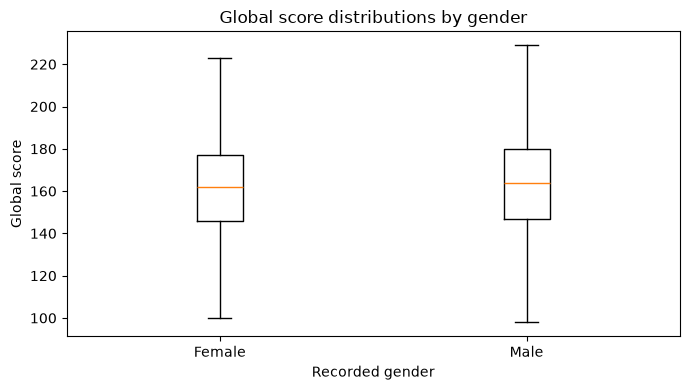

In [13]:
# Figure 3: Global-score distributions by gender.
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([female, male], showfliers=False)
ax.set_xticks([1, 2], ["Female", "Male"])
ax.set(xlabel="Recorded gender", ylabel="Global score")
ax.set_title("Global score distributions by gender")
fig.tight_layout()
fig.savefig(results / "figure3_gender.png", dpi=200)
plt.show()

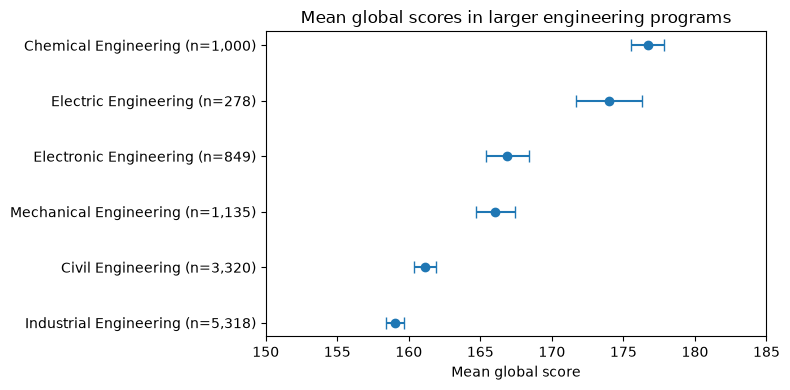

In [14]:
# Figure 4: Global scores in larger engineering programs.
large = large_programs.sort_values("mean")
labels = [f"{name.title()} (n={int(n):,})"
          for name, n in zip(large.index, large["n"])]
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(large["mean"], range(len(large)),
            xerr=large["mean"] - large["ci_low"], fmt="o", capsize=4)
ax.set_yticks(range(len(large)), labels)
ax.set(xlabel="Mean global score", xlim=(150, 185))
ax.set_title("Mean global scores in larger engineering programs")
fig.tight_layout()
fig.savefig(results / "figure4_program.png", dpi=200)
plt.show()

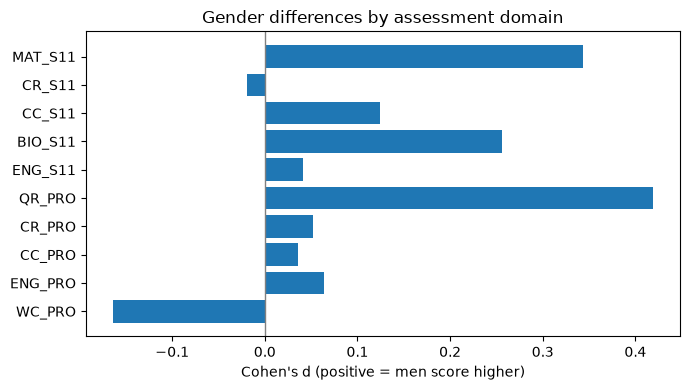

In [15]:
# Figure 5: Gender gap by assessment domain (Cohen's d).
plot = gender_by_domain.drop(index="G_SC")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(range(len(plot)), plot["cohens_d"])
ax.axvline(0, color="grey", linewidth=1)
ax.set_yticks(range(len(plot)), plot.index)
ax.invert_yaxis()
ax.set(xlabel="Cohen's d (positive = men score higher)")
ax.set_title("Gender differences by assessment domain")
fig.tight_layout()
fig.savefig(results / "figure5_gender_domains.png", dpi=200)
plt.show()

## 9. Additional checks
ANOVA tests whether the group means differ. Eta squared describes the share of score variation between groups; the father and mother values cannot be added. These ANOVA tests assume independent records and equal variances and do not adjust across the three grouping variables. Tukey's test above adjusts for the 15 stratum comparisons.

I also repeat the main gaps after keeping one record per university-test code to check whether repeated codes change the results.

In [16]:
checks = []
for col in ["EDU_FATHER", "EDU_MOTHER", "STRATUM"]:
    known = df[~df[col].isin(["0", "Not sure"])]
    groups = [group["G_SC"].to_numpy() for _, group in known.groupby(col)]
    test = stats.f_oneway(*groups)
    means = known.groupby(col)["G_SC"].mean()
    counts = known.groupby(col)["G_SC"].count()
    between = (counts * (means - known["G_SC"].mean()) ** 2).sum()
    total = ((known["G_SC"] - known["G_SC"].mean()) ** 2).sum()
    checks.append({"group": col, "n": len(known), "groups": len(groups),
                   "ANOVA_F": test.statistic, "p": test.pvalue,
                   "eta_squared": between / total})
checks = pd.DataFrame(checks)
display(checks)
checks.to_csv(results / "association_checks.csv", index=False)

unique_pro = df.drop_duplicates("Cod_SPro", keep="first")
rows = []
for frame in [df, unique_pro]:
    s = frame.groupby("STRATUM")["G_SC"].mean()
    g = frame.groupby("GENDER")["G_SC"].mean()
    f = frame.groupby("EDU_FATHER")["G_SC"].mean()
    m = frame.groupby("EDU_MOTHER")["G_SC"].mean()
    rows.append({"n": len(frame),
                 "stratum_gap": s["Stratum 6"] - s["Stratum 1"],
                 "gender_gap": g["M"] - g["F"],
                 "father_gap": f["Postgraduate education"] - f["Complete Secundary"],
                 "mother_gap": m["Postgraduate education"] - m["Complete Secundary"]})
sensitivity = pd.DataFrame(rows, index=["All supplied records", "One record per professional code"])
display(sensitivity.round(3))
sensitivity.to_csv(results / "identifier_sensitivity.csv")

,group,n,groups,ANOVA_F,p,eta_squared
0,EDU_FATHER,11613,10,107.295544,6.157818e-194,0.076831
1,EDU_MOTHER,11844,10,106.680086,5.529989e-193,0.075044
2,STRATUM,12397,6,286.063710,1.425599e-290,0.103486


,n,stratum_gap,gender_gap,father_gap,mother_gap
All supplied records,12411,29.158,2.413,18.199,17.166
One record per professional code,12395,29.124,2.392,18.192,17.193


### 9b. Add control variables
I fit three regressions with the same 11,488 complete records:

- Model A includes both parents' education.
- Model B adds stratum, gender, school type, and internet access.
- Model C also includes the student's Saber 11 average.

The coefficients are in global-score points. They describe adjusted associations, not causal effects. The confidence intervals use ordinary OLS standard errors, without adjustment for students attending the same university.

In [17]:
edu_group = {"Ninguno": "Primary or less", "Incomplete primary": "Primary or less", "Complete primary": "Primary or less",
             "Incomplete Secundary": "Secondary", "Complete Secundary": "Secondary",
             "Incomplete technical or technological": "Technical or some college",
             "Complete technique or technology": "Technical or some college",
             "Incomplete Professional Education": "Technical or some college",
             "Complete professional education": "University degree or more",
             "Postgraduate education": "University degree or more"}
reg = df[df["STRATUM"] != "0"].copy()
reg["EDU_M"] = reg["EDU_MOTHER"].map(edu_group)
reg["EDU_F"] = reg["EDU_FATHER"].map(edu_group)
reg = reg.dropna(subset=["EDU_M", "EDU_F"])
for col in ["EDU_M", "EDU_F", "STRATUM", "GENDER", "SCHOOL_NAT"]:
    reg[col] = reg[col].astype(str)
reg["INTERNET_YES"] = (reg["INTERNET"] == "Yes").astype(int)

ref = "Treatment(reference='Primary or less')"
# Add controls to the same starting model.
formula_a = f"G_SC ~ C(EDU_M, {ref}) + C(EDU_F, {ref})"
formula_b = formula_a + " + C(STRATUM) + C(GENDER) + C(SCHOOL_NAT) + INTERNET_YES"
formula_c = formula_b + " + S11_AVG"
models = {
    "A: parental education only": formula_a,
    "B: + stratum, gender, school sector, internet": formula_b,
    "C: + own Saber 11 average": formula_c,
}
rows = []
model_fits = {}
for name, formula in models.items():
    fit = smf.ols(formula, data=reg).fit()
    model_fits[name] = fit
    p = fit.params
    rows.append({"model": name, "n": int(fit.nobs), "R2": fit.rsquared,
                 "mother univ+ vs primary or less": p[f"C(EDU_M, {ref})[T.University degree or more]"],
                 "father univ+ vs primary or less": p[f"C(EDU_F, {ref})[T.University degree or more]"],
                 "Stratum 6 vs Stratum 1": p.get("C(STRATUM)[T.Stratum 6]", np.nan),
                 "male vs female": p.get("C(GENDER)[T.M]", np.nan)})
adjusted = pd.DataFrame(rows).set_index("model")
display(adjusted.round(2))
adjusted.to_csv(results / "adjusted_gaps.csv")
parent_gap = (
    adjusted.iloc[0]["mother univ+ vs primary or less"]
    + adjusted.iloc[0]["father univ+ vs primary or less"]
)
print(f"Model A, both parents university+ versus primary or less: {parent_gap:.1f} points")
print("Gap in SD units:", round(parent_gap / df["G_SC"].std(), 2))

# Confidence intervals for the main comparisons.
terms = {"Mother: university+ vs primary or less": f"C(EDU_M, {ref})[T.University degree or more]",
         "Father: university+ vs primary or less": f"C(EDU_F, {ref})[T.University degree or more]",
         "Stratum 6 vs Stratum 1": "C(STRATUM)[T.Stratum 6]",
         "Male vs female": "C(GENDER)[T.M]"}
coefficient_rows = []
for name, fit in model_fits.items():
    for label, term in terms.items():
        if term in fit.params:
            low, high = fit.conf_int().loc[term]
            coefficient_rows.append({"model": name, "comparison": label, "n": int(fit.nobs),
                                     "coefficient": fit.params[term], "ci_low": low, "ci_high": high,
                                     "p": fit.pvalues[term]})
coefficient_details = pd.DataFrame(coefficient_rows)
display(coefficient_details.round(4))
coefficient_details.to_csv(results / "regression_coefficients.csv", index=False)


,n,R2,mother univ+ vs primary or less,father univ+ vs primary or less,Stratum 6 vs Stratum 1,male vs female
model,,,,,,
A: parental education only,11488,0.08,9.81,8.50,NaN,NaN
"B: + stratum, gender, school sector, internet",11488,0.14,4.72,3.14,18.42,2.08
C: + own Saber 11 average,11488,0.61,0.71,-0.13,0.37,-0.78


Model A, both parents university+ versus primary or less: 18.3 points
Gap in SD units: 0.79


,model,comparison,n,coefficient,ci_low,ci_high,p
0,A: parental education only,Mother: university+ vs primary or less,11488,9.8148,8.0501,11.5794,0.0000
1,A: parental education only,Father: university+ vs primary or less,11488,8.4981,6.9084,10.0877,0.0000
2,"B: + stratum, gender, school sector, internet",Mother: university+ vs primary or less,11488,4.7167,2.9558,6.4775,0.0000
3,"B: + stratum, gender, school sector, internet",Father: university+ vs primary or less,11488,3.1402,1.5433,4.7371,0.0001
4,"B: + stratum, gender, school sector, internet",Stratum 6 vs Stratum 1,11488,18.4222,15.7685,21.0758,0.0000
5,"B: + stratum, gender, school sector, internet",Male vs female,11488,2.0836,1.2801,2.8872,0.0000
6,C: + own Saber 11 average,Mother: university+ vs primary or less,11488,0.7100,-0.4776,1.8976,0.2413
7,C: + own Saber 11 average,Father: university+ vs primary or less,11488,-0.1252,-1.2019,0.9515,0.8197
8,C: + own Saber 11 average,Stratum 6 vs Stratum 1,11488,0.3666,-1.4454,2.1787,0.6917
9,C: + own Saber 11 average,Male vs female,11488,-0.7810,-1.3242,-0.2378,0.0048


## 10. Findings and recommendations

**Parental education.** Students with more educated parents tend to score higher. The postgraduate-versus-secondary gap is 18.20 points for fathers and 17.17 for mothers. In Model A, the contrast between two university-educated parents and two parents with primary education or less is 18.3 points. After adding the other controls and Saber 11 average, the mother coefficient is +0.71 and the father coefficient is −0.13. Both confidence intervals include zero. This suggests that prior performance matters for interpreting the raw parental gap, but does not establish a causal explanation.

**Stratum.** Stratum 6 has the highest global mean (181.51), compared with 152.35 in Stratum 1. All 15 Tukey comparisons are significant under the test's assumptions. The Stratum 6–1 gap is about 1.5 SD on the high-school average and 1.3 SD on the university global score. These are relative positions on different tests. English has the largest standardized stratum gap at both assessments. In Model C, the global-score coefficient for Stratum 6 versus 1 is only +0.37, with a confidence interval that includes zero.

**Gender.** The male mean is 163.69 and the female mean is 161.28. The 2.41-point gap is statistically significant but small (d = 0.105). Men have a higher quantitative-reasoning mean (d = 0.42), while women have a higher writing mean (d = −0.16). Adding the Saber 11 average changes the adjusted male–female coefficient from +2.08 to −0.78. The small female advantage in Model C is statistically significant under ordinary OLS errors (p = .005).

**Programs.** The five high-school subjects explain about 61% of global-score variation. Among the six larger programs, chemical engineering has the highest raw mean and mean residual (+3.3 points). Mechanical engineering's residual mean is −1.2. These comparisons account for prior scores, but leave out other student and university differences.

I would start with a small support pilot and evaluate it before expanding it:

- Use individual entry assessments to identify needs. Family background and access information can help reach students, while support remains available to students from any group.
- Test English support for students with low scores, given the large English gaps between strata.
- Try writing workshops in mechanical, electronic, and civil engineering, whose writing means are 50.5, 51.2, and 51.3. Industrial engineering has the largest sample and is another useful setting. Chemical engineering's higher mean (64.0) gives a reason to examine its writing activities, without assuming they caused the difference.
- Report program sample sizes and prior scores alongside final averages. Explore the low female shares in mechanical, electronic, and electric engineering, without treating group averages as individual ability.
- Track participation, learning outcomes, retention, and costs. These data cannot predict how much a support program would help.

**Limitations.** The sample only includes engineering students with linked assessments who reached the final university year. It is not a representative sample of all students. Unknown labels, small program groups, and 16 repeated university-test codes also need attention. The repeat-code check changes the main gaps by less than 0.04 point, but does not explain the repeats. The regressions omit some relevant variables and do not adjust for university clustering. These results show associations, not causation.


## References
- Cohen, Jacob. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum Associates.
- De La Hoz, Enrique. (2020). *Data of Academic Performance evolution for Engineering Students*. Mendeley Data, V1. https://doi.org/10.17632/83tcx8psxv.1
- Delahoz-Dominguez, Enrique, Rohemi Zuluaga, and Tomas Fontalvo-Herrera. (2020). Dataset of academic performance evolution for engineering students. *Data in Brief*, 30, 105537. https://doi.org/10.1016/j.dib.2020.105537
- OECD. (2016). *Education in Colombia*. Reviews of National Policies for Education. OECD Publishing. https://doi.org/10.1787/9789264250604-en
- Shavelson, Richard J., et al. (2016). On the practices and challenges of measuring higher education value added: the case of Colombia. *Assessment & Evaluation in Higher Education*, 41(5), 695–720.
- pandas documentation: https://pandas.pydata.org/docs/user_guide/groupby.html
- SciPy documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
- statsmodels documentation: https://www.statsmodels.org/stable/

The confidence-interval method requires SciPy 1.11 or later. Original data labels are retained in the tables and exported files; "Ninguno" is displayed as "None" in parental-education summaries and figures.